In [2]:
import pandas as pd

pd.setoption('display.maxcolwidth', None)
pd.setoption('display.width', 2000)
pd.setoption('display.expandframerepr', False)  # Disable line-wrapping
pd.setoption('display.max rows', None)

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

coffee_data = pd.read_csv(r"..\data\reduceddata bin.csv")
df = pd.read_csv(r"..\data\reduced_data.csv")

df = pd.concat([df, coffee data["caffeine_percent"]], axis=1)

print(df.head())


   Unnamed: 0  env_71_alt  env_72_slo  env_73_asp  env_74_solrad  env_75_geo  env_76_soi  env_77_veg  env_78_wat  env_79_forcov caffeine_class  caffeine_percent
0         0.0       477.0        11.0       346.0         7929.0         5.0        15.0        12.0         6.0           68.0         Absent              0.00
1         1.0       261.0        13.0         7.0         8107.0        10.0         6.0        14.0         1.0           87.0            Low              0.03
2         2.0       253.0         1.0       247.0         7366.0        10.0        18.0         7.0         6.0            0.0         Absent              0.00
3         3.0       253.0         1.0       247.0         7366.0        10.0        18.0         7.0         6.0            0.0         Absent              0.00
4         4.0       253.0         1.0       247.0         7366.0        10.0        18.0         7.0         6.0            0.0         Absent              0.00


Soil type distribution

In [36]:
mapping_dict = {
    '5': 'Alluvio-colluvial Deposited Soils',
    '9': 'Andosols',
    '1': 'Bare Rocks',
    '7': 'Fluvio-marine Deposited Soils - Mangroves',
    '23': 'Highly Rejuvenated, Penevoluted Ferralitic Soils',
    '18': 'Humic Ferralitic Soils',
    '20': 'Humic Rejuvenated Ferralitic Soils',
    '11': 'Hydromorphic Soils',
    '19': 'Indurated-Concretion Ferralitic Soils',
    '10': 'Podzolic Soils and Podzols',
    '3': 'Poorly Evolved Erosion Soils, Lithosols',
    '2': 'Raw Lithic Mineral Soils',
    '15': 'Red Ferruginous Soils',
    '12': 'Red Fersiallitic Soils',
    '22': 'Rejuvenated Ferralitic Soils with Degrading Structure',
    '21': 'Rejuvenated Ferralitic Soils with Little Degrading Structure',
    '6': 'Salty Deposited Soils',
    '16': 'Skeletal Shallow Eroded Ferruginous Soils',
    '17': 'Typical Reddish-brown Ferralitic Soils with Little Degrading Structure',
    '8': 'Vertisols',
    '4': 'Wind-deposited Soils',
    '14': 'Yellow-red Ferruginous Soils (Red Sands)',
    '13': 'Yellow Fersiallitic Soils',
    '0': 'nodata'
}


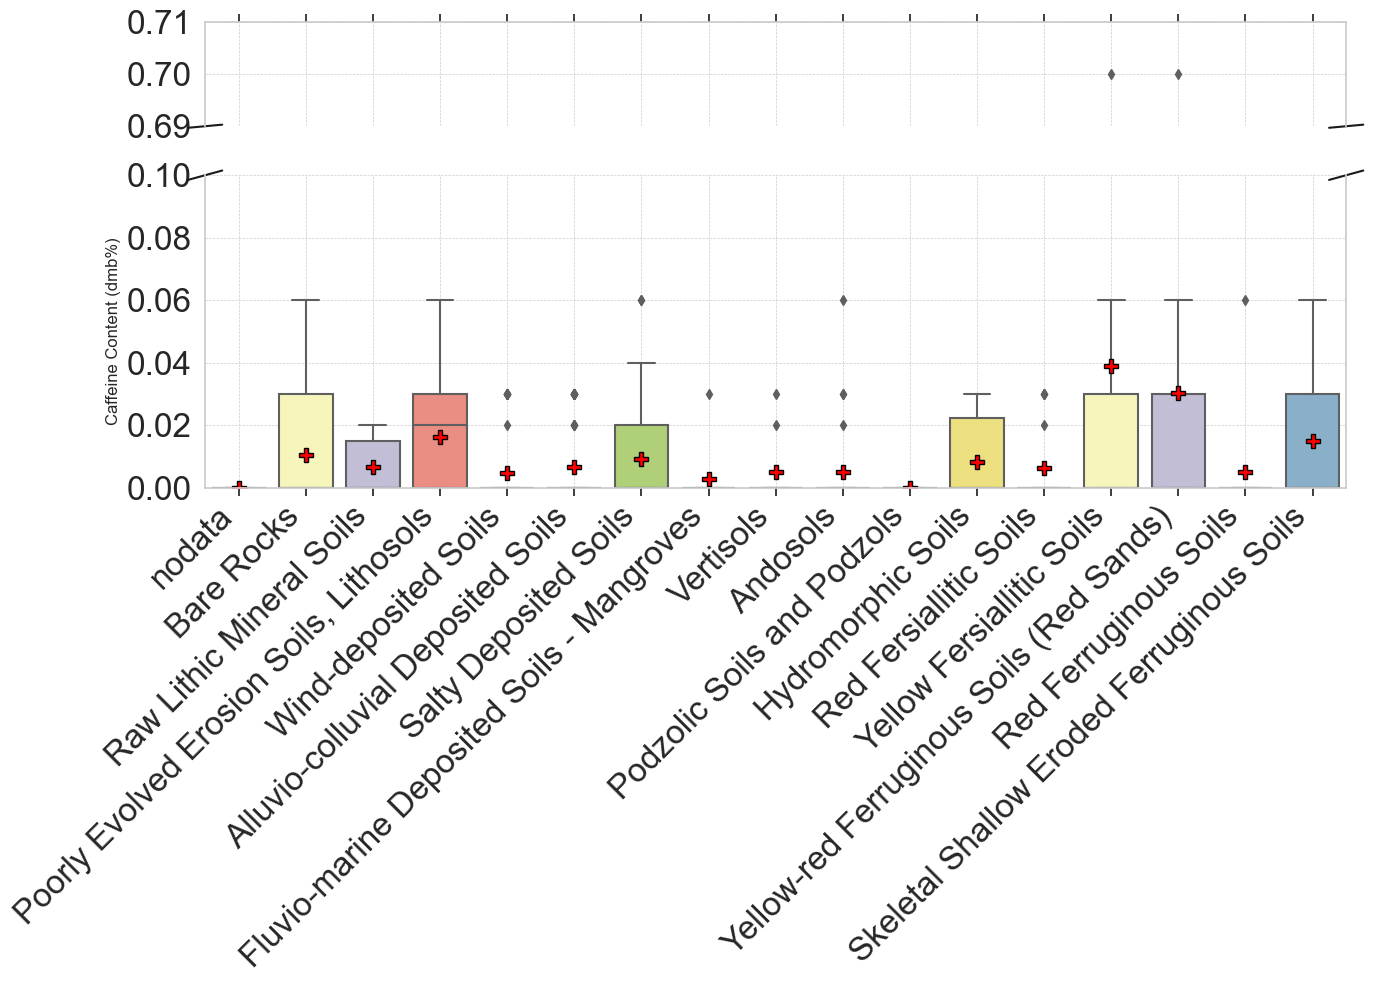

In [40]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

meanprops = {
    'marker': 'P',  # Change the marker to 'o' (circle), 's' (square), etc.
    'markerfacecolor': 'red',  # Change the fill color of the marker
    'markeredgecolor': 'black',  # Change the edge color of the marker
    'markersize': 10  # Change the size of the marker
}

# Set the plot style
sns.set(style="whitegrid")

# Create a figure with subplots for the box plot and violin plot (2 subplots per plot)
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(14, 10),
                         gridspec_kw={'height_ratios': [1, 3]})

# Box plot with broken y-axis
ax1 = axes[0]  # Top plot for box plot
ax2 = axes[1]  # Bottom plot for box plot

# Top plot (focused on 0.69 to 0.71 range)
sns.boxplot(x='env_76_soi', y='caffeine_percent', data=df, palette='Set3', ax=ax1, showmeans=True, meanprops=meanprops)
ax1.set_ylim(0.69, 0.71)  # Display a small range above the break
ax1.set_yticks(np.arange(0.69, 0.71, 0.01))  # Adjust interval for the narrow section

# Bottom plot (below 0.1)
sns.boxplot(x='env_76_soi', y='caffeine_percent', data=df, palette='Set3', ax=ax2, showmeans=True, meanprops=meanprops)
ax2.set_ylim(0, 0.1)  # Emphasize the main range
ax2.set_yticks(np.arange(0, 0.11, 0.02))  # Set interval for the bottom part

ax1.tick_params(axis='both', which='major', labelsize=24)  # Increase font size for the top plot
ax2.tick_params(axis='both', which='major', labelsize=24)  # Increase font size for the bottom plot

# Formatting for better visualization
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # Don't put tick labels at the top
ax2.xaxis.tick_bottom()

# Add diagonal lines to indicate the break in the y-axis
d = .015  # How big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

# Set labels and titles for box plot
ax2.set_xlabel('')
ax2.set_ylabel('Caffeine Content (dmb%)')
ax1.set_ylabel('')  # Remove y-axis label from the top plot
ax1.set_xlabel('')  # Remove y-axis label from the top plot
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)

current_labels = plt.gca().get_xticks()
new_labels = [mapping_dict.get(str(int(label)), label) for label in current_labels]  # Convert labels to int and then to str for matching

plt.gca().set_xticklabels(new_labels, rotation=45, ha='right')  # Rotate labels 45 degrees and align to the right


plt.tight_layout()
plt.show()

Rock types

In [41]:
mapping_dict = {
    '1': 'Alluvial & Lake deposits',
    '10': 'Basement Rocks (Ign & Met)',
    '9': 'Lavas (including Basalts & Gabbros)',
    '4': 'Mangrove Swamp',
    '13': 'Marble (Cipolin)',
    '7': 'Mesozoic Limestones + Marls (inc. "Tsingy")',
    '12': 'Quartzites',
    '3': '',
    '6': 'Sandstones',
    '5': 'Tertiary Limestones + Marls & Chalks',
    '11': 'Ultrabasics',
    '2': 'Unconsolidated Sands',
    '0': 'nodata'
}


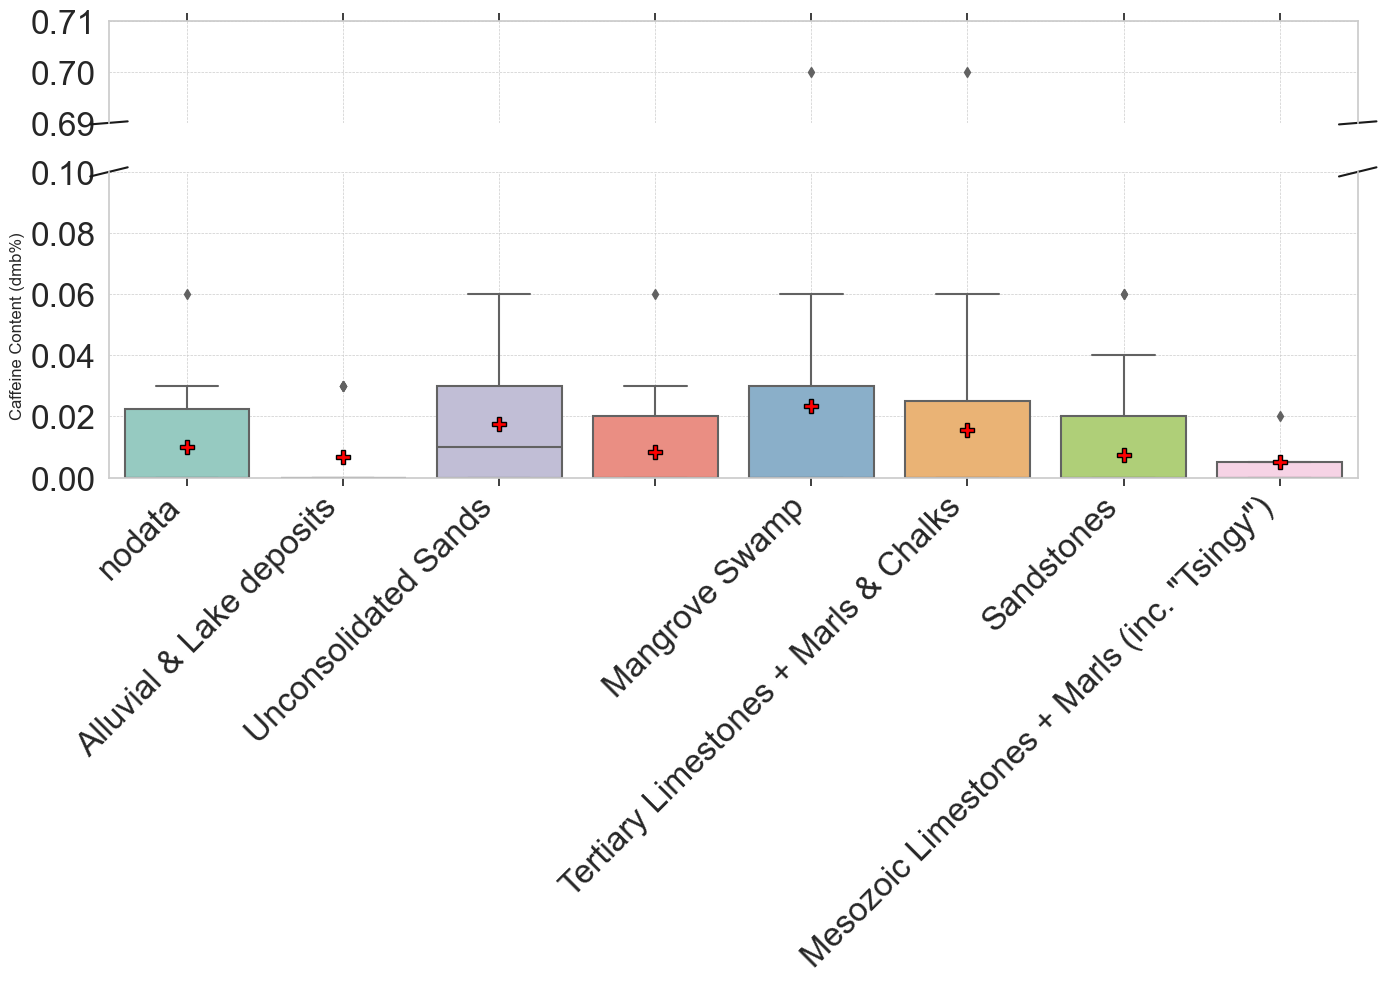

In [44]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

meanprops = {
    'marker': 'P',  # Change the marker to 'o' (circle), 's' (square), etc.
    'markerfacecolor': 'red',  # Change the fill color of the marker
    'markeredgecolor': 'black',  # Change the edge color of the marker
    'markersize': 10  # Change the size of the marker
}

# Set the plot style
sns.set(style="whitegrid")

# Create a figure with subplots for the box plot and violin plot (2 subplots per plot)
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(14, 10),
                         gridspec_kw={'height_ratios': [1, 3]})

# Box plot with broken y-axis
ax1 = axes[0]  # Top plot for box plot
ax2 = axes[1]  # Bottom plot for box plot

# Top plot (focused on 0.69 to 0.71 range)
sns.boxplot(x='env_75_geo', y='caffeine_percent', data=df, palette='Set3', ax=ax1, showmeans=True, meanprops=meanprops)
ax1.set_ylim(0.69, 0.71)  # Display a small range above the break
ax1.set_yticks(np.arange(0.69, 0.71, 0.01))  # Adjust interval for the narrow section

# Bottom plot (below 0.1)
sns.boxplot(x='env_75_geo', y='caffeine_percent', data=df, palette='Set3', ax=ax2, showmeans=True, meanprops=meanprops)
ax2.set_ylim(0, 0.1)  # Emphasize the main range
ax2.set_yticks(np.arange(0, 0.11, 0.02))  # Set interval for the bottom part
ax1.tick_params(axis='both', which='major', labelsize=24)  # Increase font size for the top plot
ax2.tick_params(axis='both', which='major', labelsize=24)  # Increase font size for the bottom plot
# Formatting for better visualization
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # Don't put tick labels at the top
ax2.xaxis.tick_bottom()

# Add diagonal lines to indicate the break in the y-axis
d = .015  # How big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

# Set labels and titles for box plot
ax2.set_xlabel('')
ax2.set_ylabel('Caffeine Content (dmb%)')
ax1.set_ylabel('')  # Remove y-axis label from the top plot
ax1.set_xlabel('')  # Remove y-axis label from the top plot
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)

current_labels = plt.gca().get_xticks()
new_labels = [mapping_dict.get(str(int(label)), label) for label in current_labels]  # Convert labels to int and then to str for matching

plt.gca().set_xticklabels(new_labels, rotation=45, ha='right')  # Rotate labels 45 degrees and align to the right


plt.tight_layout()
plt.show()

Watersheds

In [46]:
mapping_dict = {
    '9': 'CoE E-Betsiboka S-Maevarano',
    '1': 'CoE N-Bemarivo',
    '10': 'CoE N-Maevarano S-Sambirano',
    '12': 'CoE N-Mahavavy',
    '7': 'CoE N-Mangoky S-Tsiribihina',
    '11': 'CoE N-Sambirano W-Mahavavy',
    '8': 'CoE N-Tsiribihina W-Betsiboka',
    '2': 'CoE S-Bemarivo N-Mangoro',
    '6': '',
    '4': 'CoE S-Manampatrana N-Mananara',
    '5': 'CoE S-Mananara',
    '20': 'CoE S-Mangoky',
    '3': 'CoE S-Mangoro N-Manampatrana',
    '14': 'RetDisp Antainambalana',
    '13': 'RetDisp Bemarivo',
    '22': 'RetDisp Betsiboka',
    '23': 'RetDisp Maevarana (1/2 N)',
    '25': 'RetDisp Mahavavy',
    '16': 'RetDisp Manampatrana',
    '17': 'RetDisp Mananara du Sud',
    '1': 'RetDisp Mandrare',
    '18': 'RetDisp Mangoky',
    '15': 'RetDisp Mangoro',
    '19': 'RetDisp Onilahy',
    '24': 'RetDisp Sambirano',
    '21': 'RetDisp Tsiribihina',
    '0': 'nodata'
}


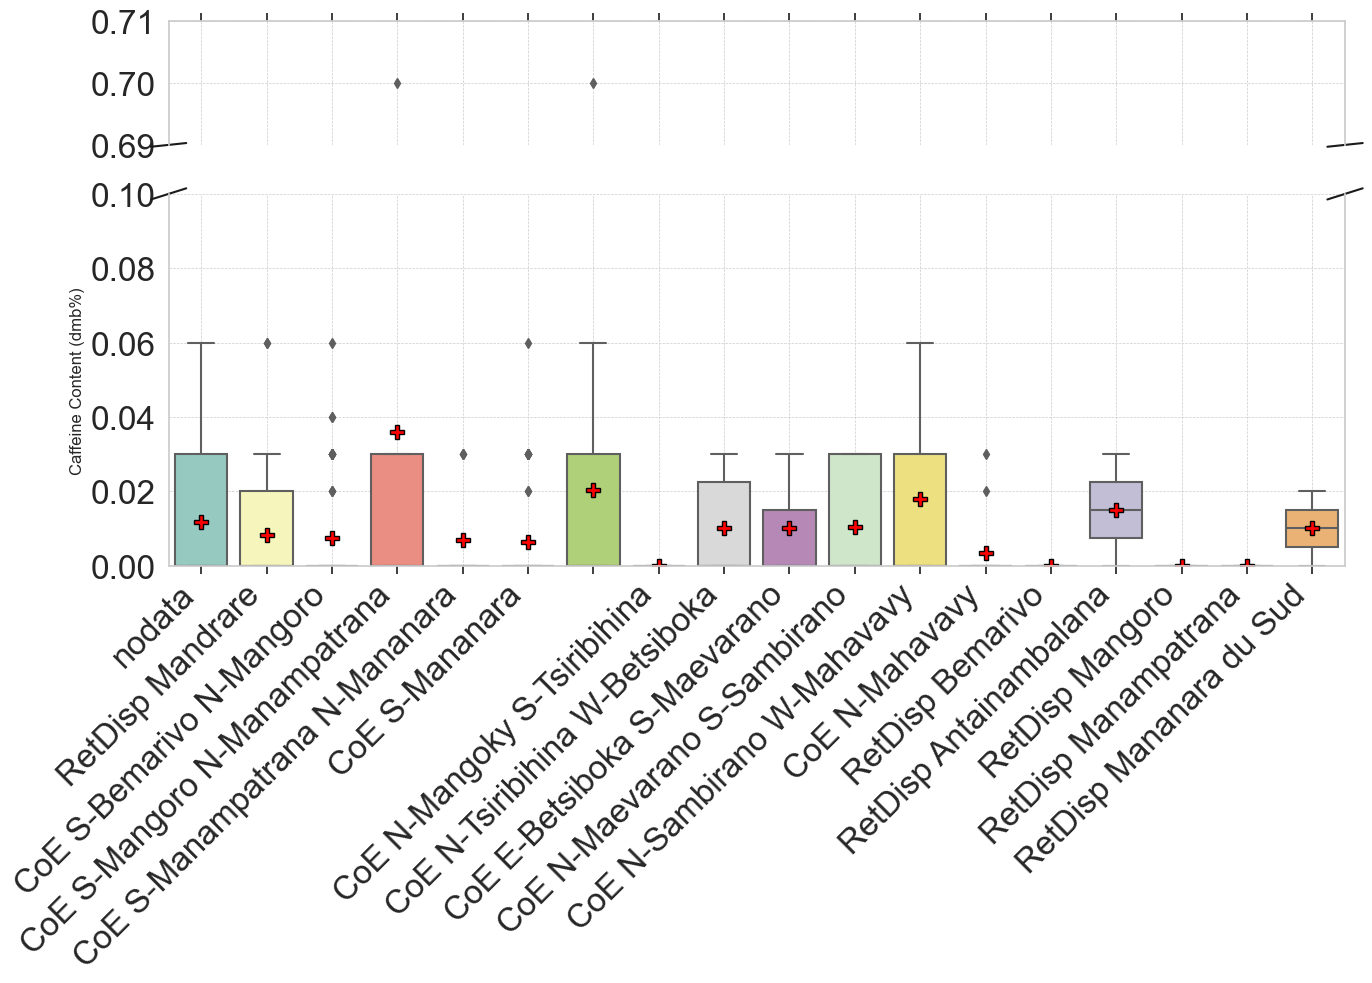

In [47]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

meanprops = {
    'marker': 'P',  # Change the marker to 'o' (circle), 's' (square), etc.
    'markerfacecolor': 'red',  # Change the fill color of the marker
    'markeredgecolor': 'black',  # Change the edge color of the marker
    'markersize': 10  # Change the size of the marker
}

# Set the plot style
sns.set(style="whitegrid")

# Create a figure with subplots for the box plot and violin plot (2 subplots per plot)
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(14, 10),
                         gridspec_kw={'height_ratios': [1, 3]})

# Box plot with broken y-axis
ax1 = axes[0]  # Top plot for box plot
ax2 = axes[1]  # Bottom plot for box plot

# Top plot (focused on 0.69 to 0.71 range)
sns.boxplot(x='env_78_wat', y='caffeine_percent', data=df, palette='Set3', ax=ax1, showmeans=True, meanprops=meanprops)
ax1.set_ylim(0.69, 0.71)  # Display a small range above the break
ax1.set_yticks(np.arange(0.69, 0.71, 0.01))  # Adjust interval for the narrow section

# Bottom plot (below 0.1)
sns.boxplot(x='env_78_wat', y='caffeine_percent', data=df, palette='Set3', ax=ax2, showmeans=True, meanprops=meanprops)
ax2.set_ylim(0, 0.1)  # Emphasize the main range
ax2.set_yticks(np.arange(0, 0.11, 0.02))  # Set interval for the bottom part
ax1.tick_params(axis='both', which='major', labelsize=24)  # Increase font size for the top plot
ax2.tick_params(axis='both', which='major', labelsize=24)  # Increase font size for the bottom plot
# Formatting for better visualization
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # Don't put tick labels at the top
ax2.xaxis.tick_bottom()

# Add diagonal lines to indicate the break in the y-axis
d = .015  # How big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

# Set labels and titles for box plot
ax2.set_xlabel('')
ax2.set_ylabel('Caffeine Content (dmb%)')
ax1.set_ylabel('')  # Remove y-axis label from the top plot
ax1.set_xlabel('')  # Remove y-axis label from the top plot
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)

current_labels = plt.gca().get_xticks()
new_labels = [mapping_dict.get(str(int(label)), label) for label in current_labels]  # Convert labels to int and then to str for matching

plt.gca().set_xticklabels(new_labels, rotation=45, ha='right')  # Rotate labels 45 degrees and align to the right


plt.tight_layout()
plt.show()

Vegetation

In [48]:
mapping_dict = {
    '1': 'South western coastal bushland',
    '2': 'Degraded south western dry spiny forest',
    '3': 'Tapia forest',
    '4': 'Cultivatation',
    '5': 'Western dry forest',
    '6': 'Plateau grassland-wooded grassland mosaic',
    '7': 'Wooded grassland-bushland mosaic',
    '8': '',
    '9': '',
    '10': 'Bare Soil/rock',
    '11': 'Wetlands',
    '12': 'South western dry spiny forest-thicket',
    '13': 'Western sub-humid forest',
    '14': 'Humid Forest',
    '15': '',
    '16': 'Degraded Humid Forest',
    '19': 'Littoral forest',
    '22': 'Mangroves',
    '23': 'Western humid forest',
    '25': 'Sea/Water',
    '0': 'Other'
}


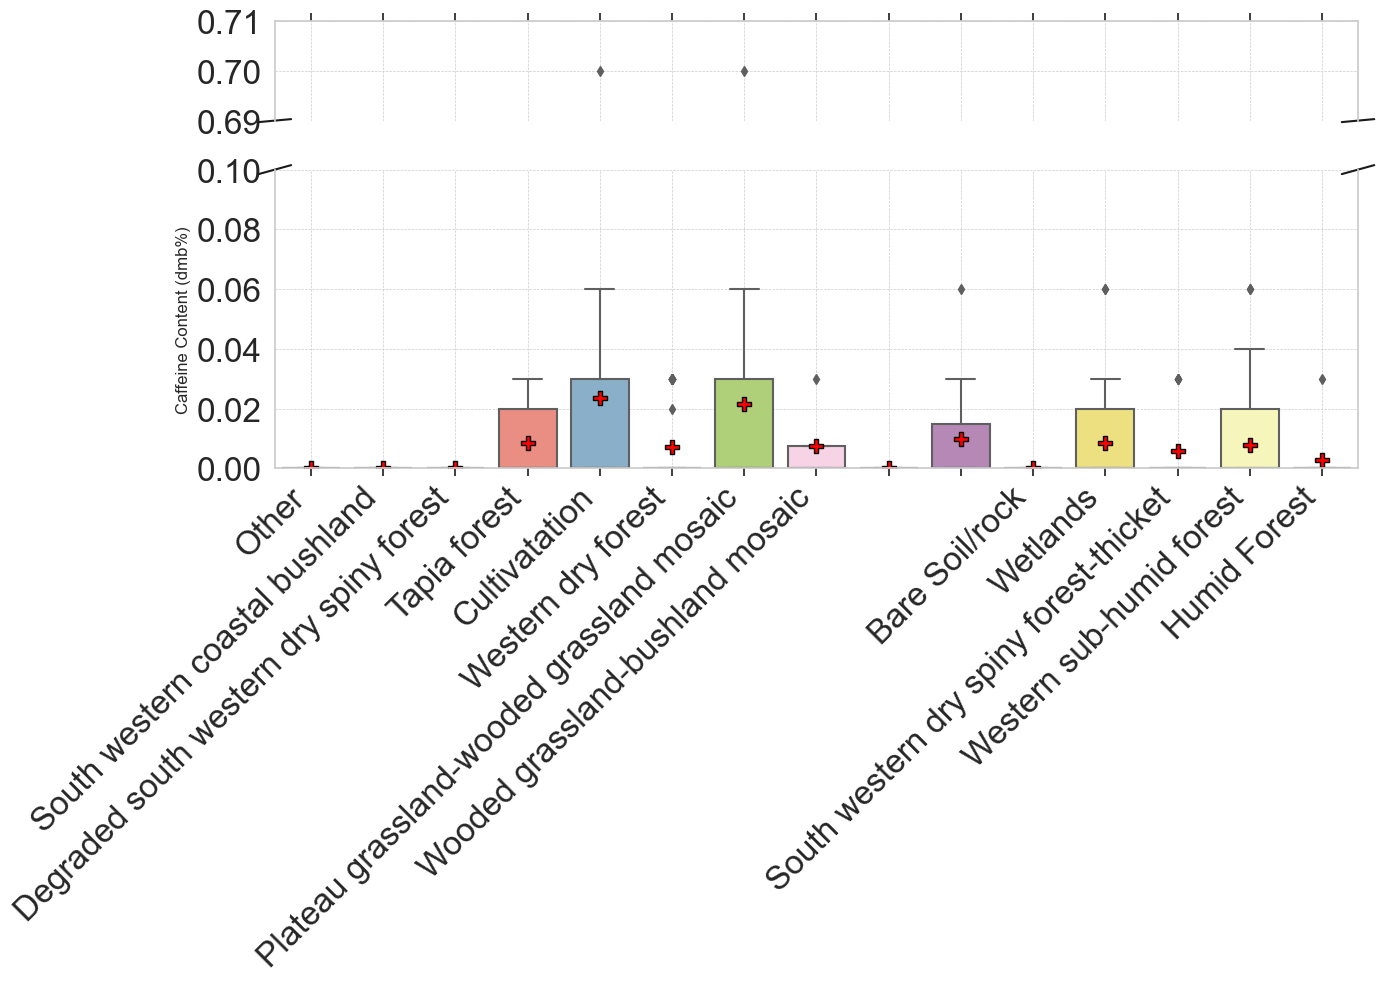

In [49]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

meanprops = {
    'marker': 'P',  # Change the marker to 'o' (circle), 's' (square), etc.
    'markerfacecolor': 'red',  # Change the fill color of the marker
    'markeredgecolor': 'black',  # Change the edge color of the marker
    'markersize': 10  # Change the size of the marker
}

# Set the plot style
sns.set(style="whitegrid")

# Create a figure with subplots for the box plot and violin plot (2 subplots per plot)
fig, axes = plt.subplots(2, 1, sharex=True, figsize=(14, 10),
                         gridspec_kw={'height_ratios': [1, 3]})

# Box plot with broken y-axis
ax1 = axes[0]  # Top plot for box plot
ax2 = axes[1]  # Bottom plot for box plot

# Top plot (focused on 0.69 to 0.71 range)
sns.boxplot(x='env_77_veg', y='caffeine_percent', data=df, palette='Set3', ax=ax1, showmeans=True, meanprops=meanprops)
ax1.set_ylim(0.69, 0.71)  # Display a small range above the break
ax1.set_yticks(np.arange(0.69, 0.71, 0.01))  # Adjust interval for the narrow section

# Bottom plot (below 0.1)
sns.boxplot(x='env_77_veg', y='caffeine_percent', data=df, palette='Set3', ax=ax2, showmeans=True, meanprops=meanprops)
ax2.set_ylim(0, 0.1)  # Emphasize the main range
ax2.set_yticks(np.arange(0, 0.11, 0.02))  # Set interval for the bottom part
ax1.tick_params(axis='both', which='major', labelsize=24)  # Increase font size for the top plot
ax2.tick_params(axis='both', which='major', labelsize=24)  # Increase font size for the bottom plot
# Formatting for better visualization
ax1.spines['bottom'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax1.xaxis.tick_top()
ax1.tick_params(labeltop=False)  # Don't put tick labels at the top
ax2.xaxis.tick_bottom()

# Add diagonal lines to indicate the break in the y-axis
d = .015  # How big to make the diagonal lines in axes coordinates
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d, +d), **kwargs)  # Top-left diagonal
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # Top-right diagonal

kwargs.update(transform=ax2.transAxes)  # Switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # Bottom-left diagonal
ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # Bottom-right diagonal

# Set labels and titles for box plot
ax2.set_xlabel('')
ax2.set_ylabel('Caffeine Content (dmb%)')
ax1.set_ylabel('')  # Remove y-axis label from the top plot
ax1.set_xlabel('')  # Remove y-axis label from the top plot
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)

current_labels = plt.gca().get_xticks()
new_labels = [mapping_dict.get(str(int(label)), label) for label in current_labels]  # Convert labels to int and then to str for matching

plt.gca().set_xticklabels(new_labels, rotation=45, ha='right')  # Rotate labels 45 degrees and align to the right


plt.tight_layout()
plt.show()